In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.research_config import ResearchConfig
from src.backtest import precompute_oos_ewma_volatility


# 05 EWMA Volatility Model

Calculate the lagged volatility matrix used by the synthetic options. At date t the variance includes returns only through t minus one.

Run cells from top to bottom, or choose **Run All** for this notebook only. Each module saves its outputs for the next notebook. Restart the kernel after pulling code changes.


## 1. Imports and saved run


In [ ]:
cfg = ResearchConfig().validate()


## 2. Load formation and test prices

The same EWMA implementation is used inside the daily backtest.


In [2]:
train_prices = pd.read_parquet("train_prices.parquet")
test_prices = pd.read_parquet("test_prices.parquet")
display(
    pd.Series(
        {
            "ewma_lambda": cfg.ewma_lambda,
            "formation_sessions": len(train_prices),
            "test_sessions": len(test_prices),
        }
    )
)


ewma_lambda              0.94
formation_sessions    1759.00
test_sessions          755.00
dtype: float64

## 3. Calculate and check volatility

Save all dates so Module 06 can inspect the actual next-close input for a snapshot signal.


,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-12-28,0.296818,0.348041,0.167195,0.224780,0.247344,0.383418,0.370316,0.324607,0.240601,0.282261,...,0.285862,0.435858,0.201443,0.262590,0.264820,0.685113,0.159067,0.224718,0.422681,0.315010
2022-12-29,0.290293,0.358540,0.163117,0.219549,0.247908,0.373132,0.367676,0.318106,0.251487,0.278493,...,0.296448,0.467773,0.197318,0.262610,0.264373,0.666197,0.155234,0.221444,0.414925,0.307962
2022-12-30,0.292054,0.364189,0.158345,0.230494,0.242418,0.369862,0.372486,0.320929,0.244713,0.273737,...,0.300186,0.457015,0.193267,0.256292,0.273427,0.690758,0.151881,0.221977,0.434753,0.319987
2023-01-03,0.284897,0.353224,0.155204,0.224226,0.235915,0.359292,0.361342,0.311154,0.237527,0.266928,...,0.293768,0.446805,0.194699,0.251522,0.267729,0.669733,0.158103,0.215449,0.421849,0.313099
2023-01-04,0.276403,0.373169,0.151607,0.217523,0.229590,0.351849,0.350363,0.304014,0.267642,0.259537,...,0.285362,0.456912,0.188780,0.279200,0.259659,0.658551,0.157045,0.208994,0.412958,0.303665


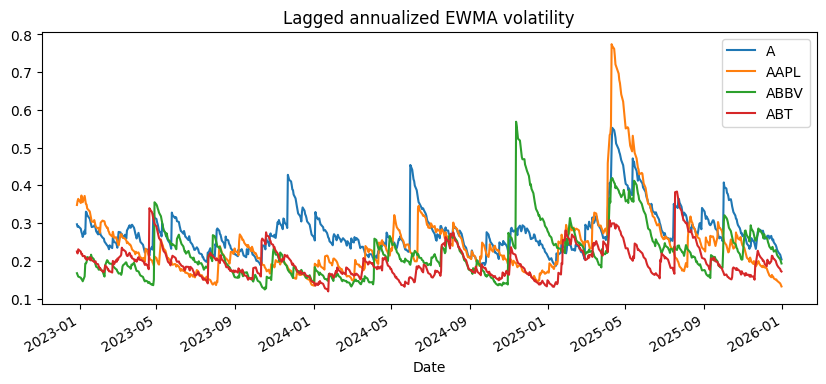

In [3]:
volatility = precompute_oos_ewma_volatility(
    train_prices, test_prices, lambda_=cfg.ewma_lambda
)
assert np.isfinite(volatility.to_numpy()).all() and (volatility > 0).all().all()
volatility.to_parquet("oos_ewma_volatility.parquet")
display(volatility.head())
volatility.iloc[:, :4].plot(figsize=(10, 4), title="Lagged annualized EWMA volatility")
plt.show()


## Save module completion

Wait for this confirmation before moving to the next notebook.
